# Задание 5. Background Detection using SVD

## Цель

Использовать сингулярное разложение для выделения фона из видео `Video_008.avi`.

По условию проекта видео необходимо представить в виде матрицы, выполнить SVD и восстановить первый кадр с помощью low-rank approximation. Нужно определить такой ранг, при котором движущиеся объекты, например автомобили, максимально исчезают, а статический фон сохраняется.

Основная идея:

```text
Видео
  ↓
кадры
  ↓
grayscale
  ↓
каждый кадр → один вектор
  ↓
матрица "кадры × пиксели"
  ↓
SVD: X = UΣVᵀ
  ↓
оставляем первые k компонент
  ↓
Xₖ = UₖΣₖVₖᵀ
  ↓
восстанавливаем первый кадр
  ↓
фон
```

Важно: матрица не центрируется по среднему. Это сделано намеренно: нам нужна доминирующая структура, присутствующая в большинстве кадров, то есть статический фон.


## 1. Импорт библиотек и параметры эксперимента

In [3]:
from pathlib import Path
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

# None = использовать все кадры.
MAX_FRAMES = None

# Шаг чтения кадров. 1 = каждый кадр.
FRAME_STEP = 1

# Уменьшение разрешения для ускорения SVD.
# 0.5 означает 50% исходной ширины и высоты.
# Для Video_008.avi это 160×120 вместо 320×240.
RESIZE_SCALE = 0.5

# Ранги для визуального сравнения.
RANKS_TO_SHOW = [1, 2, 5, 10, 20]

np.random.seed(RANDOM_STATE)


## 2. Поиск `Video_008.avi`

In [4]:
DATA_CANDIDATES = [
    Path("data/Video"),
    Path("../data/Video"),
    Path("../../data/Video"),
]

VIDEO_DIR = next(
    (path for path in DATA_CANDIDATES if (path / "Video_008.avi").exists()),
    None,
)

if VIDEO_DIR is None:
    raise FileNotFoundError(
        "Не найден Video_008.avi. Проверь путь data/Video/Video_008.avi"
    )

VIDEO_PATH = VIDEO_DIR / "Video_008.avi"

print("Видео:", VIDEO_PATH.resolve())


Видео: C:\Users\User\Desktop\ML6_Unsupervised_learning_ID_1254805-1\src\data\Video\Video_008.avi


## 3. Проверка характеристик видео

In [5]:
cap = cv2.VideoCapture(str(VIDEO_PATH))

if not cap.isOpened():
    raise RuntimeError(f"Не удалось открыть видео: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

cap.release()

duration = frame_count / fps if fps else 0

print(f"FPS: {fps}")
print(f"Кадров: {frame_count}")
print(f"Разрешение: {width} × {height}")
print(f"Длительность: {duration:.2f} сек")


FPS: 10.0
Кадров: 793
Разрешение: 320 × 240
Длительность: 79.30 сек


## 4. Читаем кадры и преобразуем их в grayscale

Каждый кадр превращаем из RGB/BGR в grayscale.

Затем, при необходимости, уменьшаем разрешение. Это не меняет сам принцип метода, но существенно уменьшает размер матрицы SVD.

Например, после уменьшения `320×240 → 160×120` один кадр содержит:

`160 × 120 = 19 200` признаков-пикселей.


In [6]:
def read_video_matrix(
    video_path: Path,
    frame_step: int = 1,
    max_frames: int | None = None,
    resize_scale: float = 1.0,
):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"Не удалось открыть видео: {video_path}")

    frames = []
    frame_numbers = []

    current_frame = 0

    while True:
        ok, frame = cap.read()

        if not ok:
            break

        if current_frame % frame_step == 0:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            if resize_scale != 1.0:
                new_width = max(1, int(gray.shape[1] * resize_scale))
                new_height = max(1, int(gray.shape[0] * resize_scale))
                gray = cv2.resize(
                    gray,
                    (new_width, new_height),
                    interpolation=cv2.INTER_AREA,
                )

            frames.append(gray)
            frame_numbers.append(current_frame)

            if max_frames is not None and len(frames) >= max_frames:
                break

        current_frame += 1

    cap.release()

    if not frames:
        raise RuntimeError("Видео не содержит доступных кадров.")

    frame_array = np.stack(frames).astype(np.float32) / 255.0
    h, w = frame_array.shape[1:]

    matrix = frame_array.reshape(frame_array.shape[0], -1)

    return matrix, frame_array, frame_numbers, h, w


start = time.perf_counter()

video_matrix, video_frames, frame_numbers, small_h, small_w = read_video_matrix(
    VIDEO_PATH,
    frame_step=FRAME_STEP,
    max_frames=MAX_FRAMES,
    resize_scale=RESIZE_SCALE,
)

read_time = time.perf_counter() - start

print("Матрица видео:", video_matrix.shape)
print(f"Размер одного кадра: {small_w} × {small_h}")
print(f"Время чтения: {read_time:.3f} сек")


Матрица видео: (792, 19200)
Размер одного кадра: 160 × 120
Время чтения: 0.918 сек


## 5. Проверка нескольких кадров

До SVD посмотрим, что видео читается корректно и что в нём действительно присутствуют движущиеся объекты.


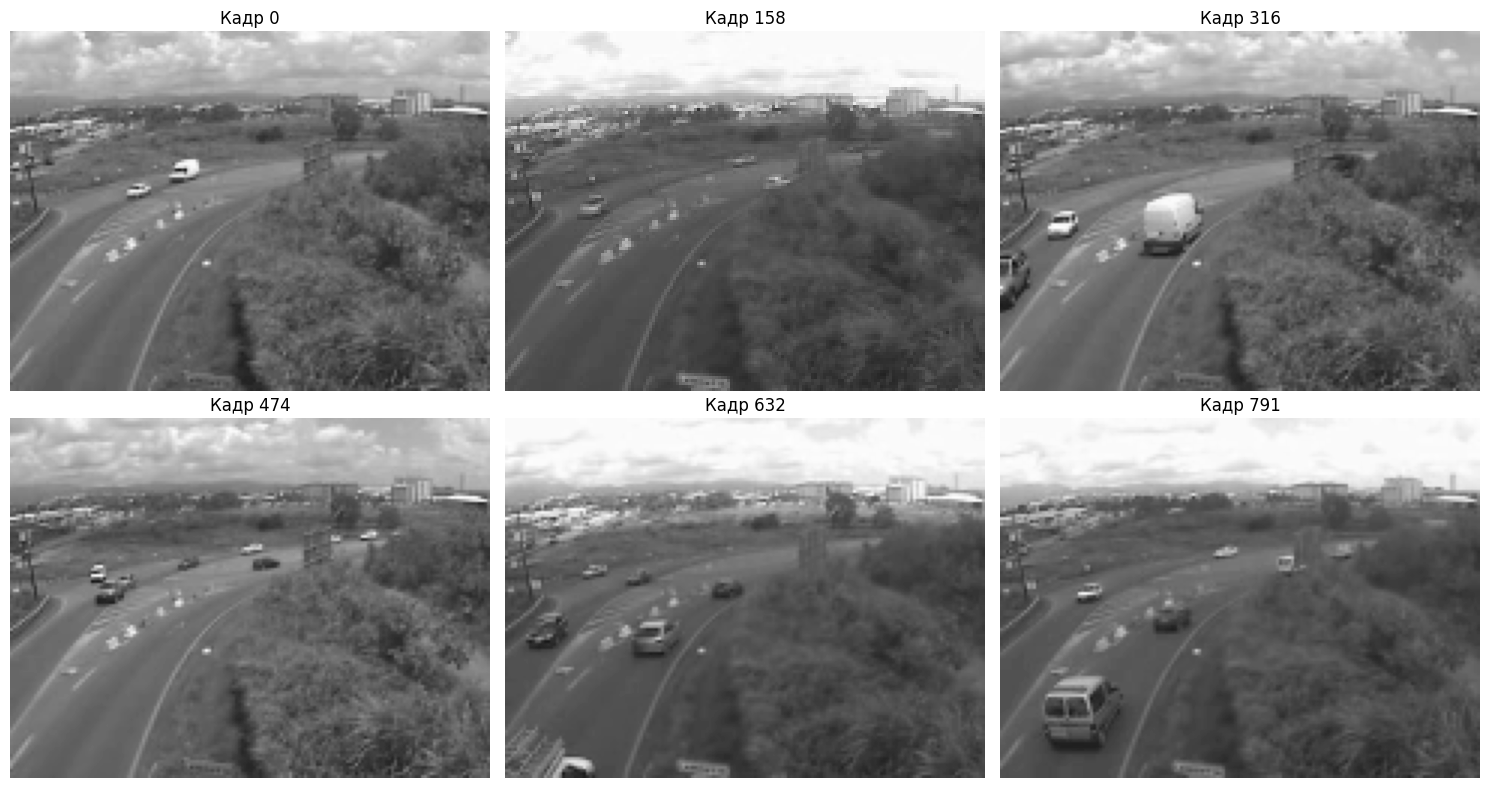

In [7]:
sample_positions = np.linspace(
    0,
    len(video_frames) - 1,
    num=min(6, len(video_frames)),
).astype(int)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, pos in zip(axes.ravel(), sample_positions):
    ax.imshow(video_frames[pos], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Кадр {frame_numbers[pos]}")
    ax.axis("off")

for ax in axes.ravel()[len(sample_positions):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# 6. SVD матрицы видео

Получаем:

$$
X = U\\Sigma V^T
$$

где:

- строки `X` соответствуют кадрам;
- столбцы `X` соответствуют пикселям;
- `Σ` содержит сингулярные значения.

Если фон практически не меняется от кадра к кадру, его структура должна иметь большой вклад в первых сингулярных компонентах.


In [8]:
start = time.perf_counter()

U, singular_values, VT = np.linalg.svd(
    video_matrix,
    full_matrices=False,
)

svd_time = time.perf_counter() - start

print("U shape:", U.shape)
print("Sigma length:", len(singular_values))
print("VT shape:", VT.shape)
print(f"SVD time: {svd_time:.3f} sec")


U shape: (792, 792)
Sigma length: 792
VT shape: (792, 19200)
SVD time: 6.318 sec


## 7. Singular value spectrum

Первое сингулярное значение особенно важно для данной задачи: если оно сильно доминирует, это означает, что в видео есть сильная общая структура, присутствующая во многих кадрах.


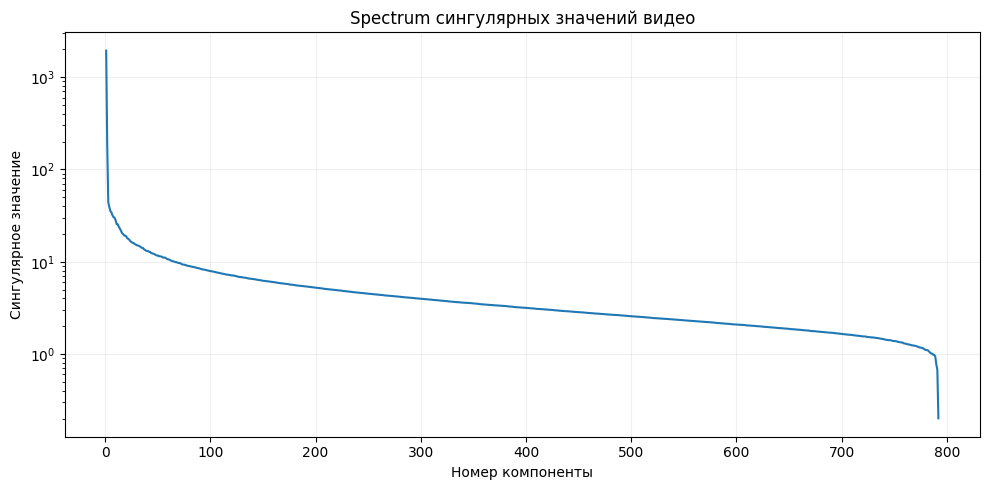

Первые 10 сингулярных значений:


,Component,Singular value
0,1,1934.430786
1,2,177.179718
2,3,43.921009
3,4,39.009457
4,5,35.346764
5,6,34.205784
6,7,31.825956
7,8,30.406219
8,9,29.953495
9,10,28.085533


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    np.arange(1, len(singular_values) + 1),
    singular_values,
    linewidth=1.5,
)

ax.set_title("Spectrum сингулярных значений видео")
ax.set_xlabel("Номер компоненты")
ax.set_ylabel("Сингулярное значение")
ax.set_yscale("log")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("Первые 10 сингулярных значений:")
display(pd.DataFrame({
    "Component": np.arange(1, min(10, len(singular_values)) + 1),
    "Singular value": singular_values[:10],
}))


## 8. Explained variance / energy

Для SVD используем долю энергии:

$$
EV(k)=
\frac{\\sum_{i=1}^{k} \\sigma_i^2}
{\\sum_{i=1}^{r} \\sigma_i^2}
$$

Высокое значение для малого `k` означает, что небольшое число компонентов описывает большую часть структуры видео.


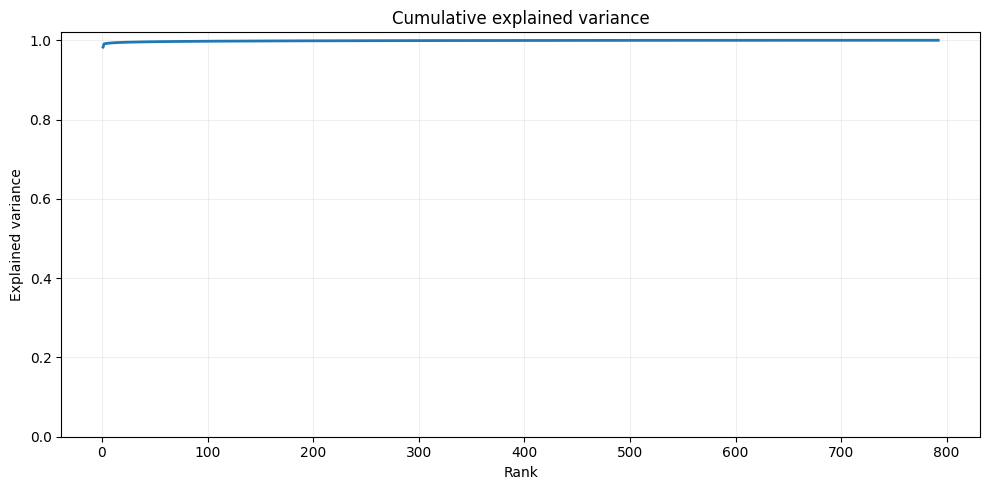

,Threshold,Required rank
0,0.90,1
1,0.95,1
2,0.99,2


In [10]:
energy = singular_values ** 2
explained_variance = np.cumsum(energy) / np.sum(energy)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    np.arange(1, len(explained_variance) + 1),
    explained_variance,
    linewidth=2,
)

ax.set_title("Cumulative explained variance")
ax.set_xlabel("Rank")
ax.set_ylabel("Explained variance")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

thresholds = [0.90, 0.95, 0.99]

variance_rows = []

for threshold in thresholds:
    rank = int(np.searchsorted(explained_variance, threshold) + 1)

    variance_rows.append({
        "Threshold": threshold,
        "Required rank": rank,
    })

variance_df = pd.DataFrame(variance_rows)
display(variance_df)


# 9. Low-rank reconstruction

Для выбранного `k`:

$$
X_k = U_k\\Sigma_kV_k^T
$$

Затем берём строку, соответствующую первому кадру, и возвращаем её из вектора обратно в форму изображения.


In [11]:
def reconstruct_frame(U, singular_values, VT, rank, frame_index):
    rank = int(rank)

    U_k = U[:, :rank]
    sigma_k = singular_values[:rank]
    VT_k = VT[:rank, :]

    reconstructed_matrix = (U_k * sigma_k) @ VT_k

    frame_vector = reconstructed_matrix[frame_index]

    # Поскольку SVD выполняется над [0, 1], ограничиваем результат этим диапазоном.
    frame = np.clip(
        frame_vector.reshape(small_h, small_w),
        0,
        1,
    )

    return frame


# 10. Первый кадр и его low-rank реконструкция

Сравниваем оригинальный первый кадр с rank-1 и несколькими более высокими рангами.

Главная цель по чек-листу: при малом rank движущиеся автомобили должны исчезнуть или стать значительно менее заметными, а статический фон должен сохраниться.


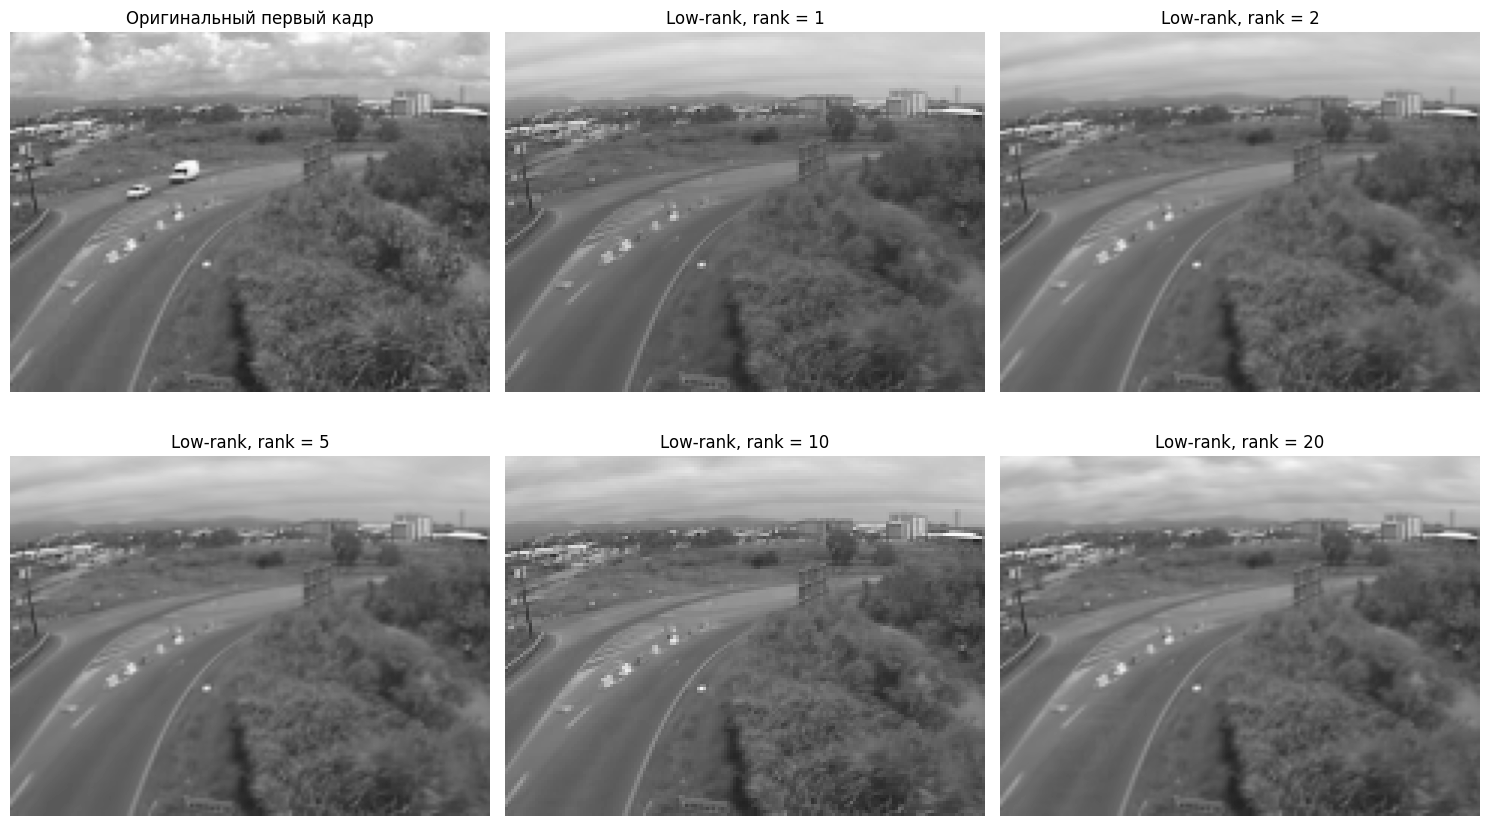

In [12]:
first_frame = video_frames[0]

valid_ranks = [
    rank
    for rank in RANKS_TO_SHOW
    if rank <= len(singular_values)
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9),
)

axes = axes.ravel()

axes[0].imshow(first_frame, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Оригинальный первый кадр")
axes[0].axis("off")

for ax, rank in zip(axes[1:], valid_ranks):
    reconstructed = reconstruct_frame(
        U,
        singular_values,
        VT,
        rank,
        frame_index=0,
    )

    ax.imshow(reconstructed, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Low-rank, rank = {rank}")
    ax.axis("off")

for ax in axes[1 + len(valid_ranks):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# 11. Подробное сравнение rank = 1, 2, 5, 10, 20

Для каждого rank одновременно показываем:

- восстановленный кадр;
- объяснённую энергию;
- относительную ошибку восстановления.

Ошибка относительно исходного кадра сама по себе не определяет качество извлечения фона: движущийся объект тоже является частью исходного кадра. Поэтому выбор rank делаем прежде всего визуально и с учётом того, насколько быстро накапливается общая энергия первых компонент.


In [13]:
analysis_rows = []

original = first_frame

for rank in valid_ranks:
    reconstructed = reconstruct_frame(
        U,
        singular_values,
        VT,
        rank,
        frame_index=0,
    )

    relative_error = (
        np.linalg.norm(original - reconstructed)
        / np.linalg.norm(original)
    )

    analysis_rows.append({
        "Rank": rank,
        "Explained energy": explained_variance[rank - 1],
        "Relative error to first frame": relative_error,
    })

analysis_df = pd.DataFrame(analysis_rows)

display(
    analysis_df.round({
        "Explained energy": 6,
        "Relative error to first frame": 6,
    })
)


,Rank,Explained energy,Relative error to first frame
0,1,0.982761,0.099858
1,2,0.991006,0.079150
2,5,0.992240,0.077932
3,10,0.993499,0.075669
4,20,0.994753,0.071130


# 12. Восстановление кадра в исходном разрешении

SVD выше выполнялся на уменьшенной копии кадра для снижения вычислительной нагрузки.

Для итоговой демонстрации увеличиваем low-rank изображение до исходного разрешения видео. Это только визуализация: сама SVD-модель строилась на матрице уменьшенного разрешения.


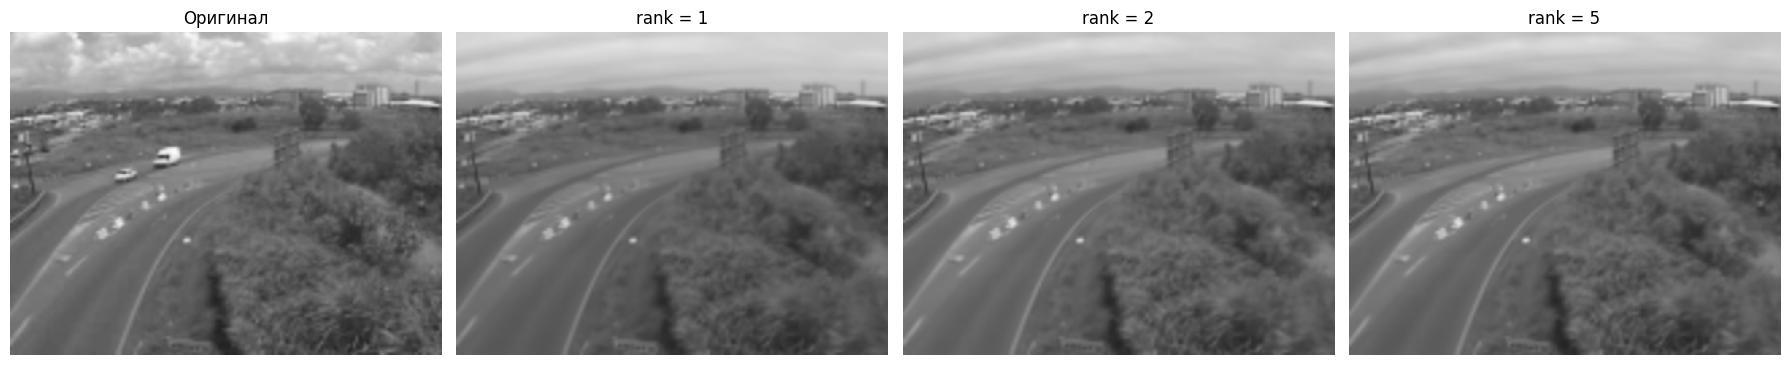

In [14]:
fig, axes = plt.subplots(
    1,
    min(4, len(valid_ranks) + 1),
    figsize=(18, 5),
)

axes = np.atleast_1d(axes)

axes[0].imshow(
    cv2.resize(
        first_frame,
        (width, height),
        interpolation=cv2.INTER_LINEAR,
    ),
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[0].set_title("Оригинал")
axes[0].axis("off")

for ax, rank in zip(axes[1:], valid_ranks[:len(axes)-1]):
    reconstructed = reconstruct_frame(
        U,
        singular_values,
        VT,
        rank,
        frame_index=0,
    )

    reconstructed_full = cv2.resize(
        reconstructed,
        (width, height),
        interpolation=cv2.INTER_LINEAR,
    )

    ax.imshow(
        reconstructed_full,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    ax.set_title(f"rank = {rank}")
    ax.axis("off")

plt.tight_layout()
plt.show()


# 13. Как выбрать rank для фона

Практический критерий:

- если `rank = 1` уже сохраняет основные неподвижные элементы и подавляет автомобили, это наиболее простой и сильный результат;
- если rank 1 слишком грубый, можно проверить `rank = 2..5`;
- при дальнейшем увеличении rank начинают возвращаться дополнительные детали, в том числе динамические объекты.

Поэтому для background detection обычно интересен **минимальный rank, который сохраняет фон с достаточным качеством**.

В финальном отчёте нужно показать исходный кадр рядом с выбранной low-rank реконструкцией и объяснить, почему выбран именно этот rank.


# 14. Финальный результат

После запуска notebook в этом разделе нужно зафиксировать фактический выбранный rank на основании полученного изображения.

Пример формулировки:

> Для выделения фона выбран `rank = ...`. При этом статические элементы сцены сохраняются, а движущиеся автомобили становятся значительно менее заметными. Увеличение rank возвращает дополнительные детали кадра и часть динамических объектов, поэтому использовать более высокий ранг для выделения чистого фона нецелесообразно.


# Контрольный список Task 5

- [x] Загружен `Video_008.avi`
- [x] Проверены FPS, число кадров и разрешение
- [x] Видео представлено как матрица `кадры × пиксели`
- [x] Кадры переведены в grayscale
- [x] Выполнен SVD
- [x] Построен spectrum сингулярных значений
- [x] Рассчитана cumulative explained energy
- [x] Выполнена low-rank reconstruction первого кадра
- [x] Сравнены разные rank
- [x] Проанализирован компромисс между детализацией и выделением фона
- [x] Подготовлен критерий выбора rank

**Главный критерий чек-листа:** движущиеся автомобили должны исчезнуть или заметно подавиться, а статический фон должен остаться максимально близким к исходному.
